<a href="https://colab.research.google.com/github/MarkusThill/MarkusThill.github.io-jupyter/blob/main/2026_09_23_weighted_recursive_least_squares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Weighted Recursive Least Squares: A Step-by-step Tutorial in Python

This notebook accompanies my blog post [Derivation of a Weighted Recursive Linear Least Squares Estimator](https://markusthill.github.io/blog/2026/derivation-of-a-weighted-recursive-least-squares-estimator/). In the post, we derived update equations that refine a linear least squares fit whenever new observations arrive, without solving the whole problem again. Here, we turn these equations into Python code.

We start with the simplest case, one new observation at a time, and implement the equations exactly as they appear in the post. Then we add one ingredient after the other and motivate each of them with a small example: the initial regularization, observation weights, forgetting of old observations, batches of observations and several outputs. After each step, we compare the recursive estimate with the direct least squares solution. This comparison is the best way to convince ourselves that the implementation does what it should. At the end, we collect everything in a small, documented class and use it for a few typical scenarios.

The notebook only needs NumPy and Matplotlib. It runs locally or in Google Colab (see the badge above).

**Contents**

1. The goal: fitting a line to a stream of data
2. The recursive update for a single observation
3. The initialization and the role of $\rho$
4. Weighting observations
5. Forgetting old observations
6. Rounding errors and the symmetry of $\mathbf{A}^{-1}$
7. Processing batches of observations
8. Several outputs at once
9. Putting it all together: the `WeightedRLS` class
10. Usage examples
11. Summary

**Notation.** The symbols follow the blog post. The table lists the names that we use for them in the code.

| Symbol | Python | Meaning |
| --- | --- | --- |
| $\mathbf{x}_{n+1}$, $y_{n+1}$, $w_{n+1}$ | `x`, `y`, `w` | New input vector, its target and its weight |
| $\boldsymbol{\theta}_n$ | `theta` | Current coefficients (a matrix $\boldsymbol{\Theta}_n$ with one column per output from Section 8 on) |
| $\mathbf{A}_n^{-1}$ | `A_inv` | Inverse of the regularized, weighted normal matrix |
| $e_{n+1}$ | `e` | Prediction error of the new observation, before the update |
| $\boldsymbol{\delta}_{n+1}$ | `delta` | Gain vector |
| $\rho$ | `rho` | Initial regularization (ridge) coefficient, $\mathbf{A}_0=\rho\mathbf{I}$ |
| $\lambda$, $\lambda_n$ | `lam`, `lam_n` | Forgetting factor, and the factor used in the current update ($\lambda_0=1$) |
| $\mathbf{X}_\mu$, $\mathbf{y}_\mu$, $\mathbf{W}_\mu$ | `X_mu`, `y_mu`, `w_mu` | A batch of $\mu$ input vectors (as rows), their targets and weights (the diagonal of $\mathbf{W}_\mu$) |
| $\mathbf{e}_\mu$, $\boldsymbol{\Delta}_\mu$ | `e_mu`, `Delta_mu` | Prediction errors and gain matrix of a batch |

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt

# Colorblind-safe colors and a calm plotting style for all figures
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]   # light to dark = early to late
INK, MUTED, POINTS = "#52514e", "#898781", "#bdbcb6"
plt.rcParams.update({
    "figure.dpi": 120, "axes.prop_cycle": plt.cycler(color=[BLUE, ORANGE, AQUA]),
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#c3c2b7",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.titlesize": 11, "axes.titlelocation": "left", "axes.labelcolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK, "ytick.labelcolor": INK,
    "legend.frameon": False, "legend.fontsize": 9, "lines.linewidth": 1.8,
})
print("NumPy", np.__version__)

NumPy 2.2.6


## 1. The Goal: Fitting a Line to a Stream of Data

Imagine that pairs $(x_i, y_i)$ arrive one after another, for example measurements from a sensor, and that we would like to know the best straight line $y \approx \theta_0 + \theta_1 x$ at any time. We write each input as a vector $\mathbf{x}_i = (1, x_i)^T$, where the constant $1$ belongs to the intercept $\theta_0$, and collect the first $n$ input vectors as rows of a matrix $\mathbf{X}_n$. The coefficients that fit the first $n$ observations best are given by the closed-form (weighted and regularized) least squares solution from the blog post,

$$\boldsymbol{\theta}_n = \big(\mathbf{X}_n^T \mathbf{W}_n \mathbf{X}_n + \rho \mathbf{I}\big)^{-1} \mathbf{X}_n^T \mathbf{W}_n \mathbf{y}_n .$$

For now, all weights are $1$ ($\mathbf{W}_n=\mathbf{I}$), and $\rho$ is a small number whose role we discuss in Section 3. We implement this direct solution first, because it will serve as our reference throughout the notebook.

In [2]:
def batch_solution(X, y, w=None, rho=0.0):
    """Direct weighted least squares solution (X^T W X + rho I)^{-1} X^T W y.

    X holds one input vector per row, y the targets (a vector, or a matrix with
    one column per output) and w the observation weights (default: all 1).
    """
    w = np.ones(len(X)) if w is None else np.asarray(w, dtype=float)
    WX = w[:, None] * X                        # W X: every row scaled by its weight
    A = X.T @ WX + rho * np.eye(X.shape[1])    # X^T W X + rho I
    b = WX.T @ y                               # X^T W y
    return np.linalg.solve(A, b)               # same as inv(A) @ b, but more accurate

Now we create a stream of $200$ noisy observations of the line $y = 1 + 0.6\,x$ and, for every $n$, compute the direct solution from the first $n$ observations. This is what the recursion will have to reproduce later.

In [3]:
rng = np.random.default_rng(1)
n_obs = 200
theta_true = np.array([1.0, 0.6])                  # true intercept and slope
x_values = rng.uniform(-3, 3, n_obs)
X = np.column_stack([np.ones(n_obs), x_values])    # input vectors (1, x_i) as rows
y = X @ theta_true + rng.normal(0, 0.8, n_obs)     # noisy targets
rho = 0.01

# Refit from scratch after every new observation (this is what we want to avoid)
refits = np.array([batch_solution(X[:n], y[:n], rho=rho) for n in range(1, n_obs + 1)])
print("coefficients after all observations:", refits[-1])

coefficients after all observations: [0.93029977 0.58172646]


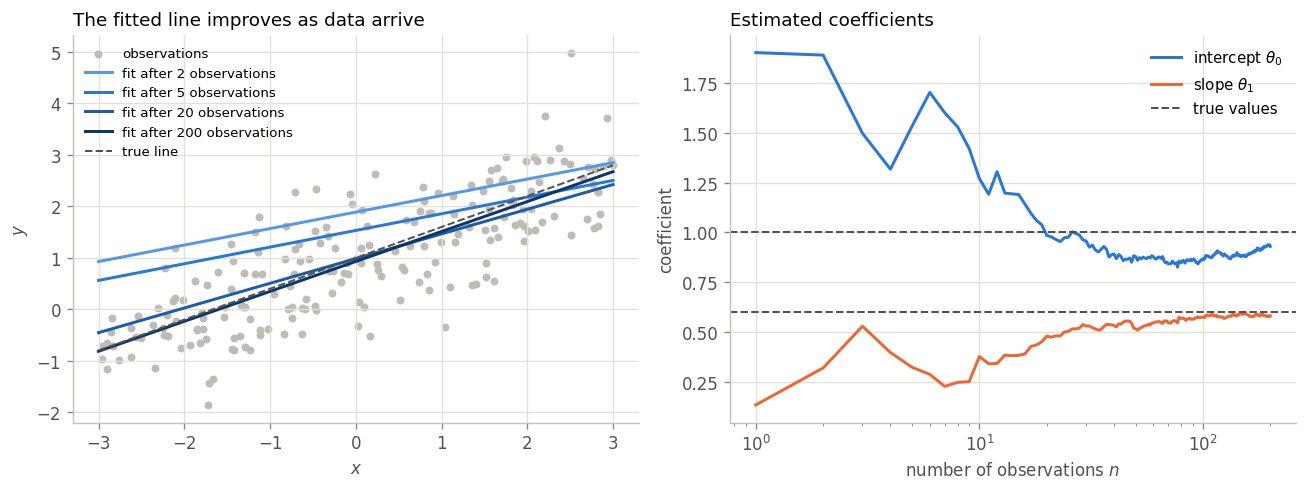

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
grid = np.array([-3.0, 3.0])
ax1.scatter(x_values, y, s=14, color=POINTS, label="observations")
for color, n in zip(RAMP[1:], [2, 5, 20, 200]):
    ax1.plot(grid, refits[n - 1, 0] + refits[n - 1, 1] * grid, color=color, label=f"fit after {n} observations")
ax1.plot(grid, theta_true[0] + theta_true[1] * grid, "--", color=INK, lw=1.2, label="true line")
ax1.set(xlabel="$x$", ylabel="$y$", title="The fitted line improves as data arrive")
ax1.legend(loc="upper left", fontsize=8)

n_axis = np.arange(1, n_obs + 1)
ax2.plot(n_axis, refits[:, 0], label=r"intercept $\theta_0$")
ax2.plot(n_axis, refits[:, 1], label=r"slope $\theta_1$")
ax2.axhline(theta_true[0], ls="--", color=INK, lw=1.2, label="true values")
ax2.axhline(theta_true[1], ls="--", color=INK, lw=1.2)
ax2.set(xscale="log", xlabel="number of observations $n$", ylabel="coefficient",
        title="Estimated coefficients")
ax2.legend()
fig.tight_layout()
plt.show()

Refitting after every observation works, but it has two drawbacks: we have to store all previous observations, and every refit builds and solves the complete problem again. The recursive least squares (RLS) update produces exactly the same coefficients from the previous coefficients, the matrix $\mathbf{A}_n^{-1}$ and the new observation alone.

## 2. The Recursive Update for a Single Observation

We begin with the special case at the end of the blog post: one new observation $(\mathbf{x}_{n+1}, y_{n+1})$ at a time. To keep things simple, all weights are $1$ and nothing is forgotten ($w_{n+1}=1$ and $\lambda_n=1$). The update then consists of four steps:

$$
\begin{aligned}
e_{n+1} &= y_{n+1}-\mathbf{x}_{n+1}^T\boldsymbol{\theta}_n, \\
\boldsymbol{\delta}_{n+1} &= \frac{\mathbf{A}_n^{-1}\mathbf{x}_{n+1}}{1+\mathbf{x}_{n+1}^T\mathbf{A}_n^{-1}\mathbf{x}_{n+1}}, \\
\boldsymbol{\theta}_{n+1} &= \boldsymbol{\theta}_n+\boldsymbol{\delta}_{n+1}e_{n+1}, \\
\mathbf{A}_{n+1}^{-1} &= \mathbf{A}_n^{-1}-\boldsymbol{\delta}_{n+1}\mathbf{x}_{n+1}^T\mathbf{A}_n^{-1}.
\end{aligned}
$$

In words: we first predict the new target with the current coefficients and measure the prediction error $e_{n+1}$. The gain vector $\boldsymbol{\delta}_{n+1}$ then determines how strongly each coefficient reacts to this error, and the coefficients are corrected accordingly. Finally, $\mathbf{A}^{-1}$ is updated for the next observation. The recursion starts with $\boldsymbol{\theta}_0=\mathbf{0}$ and $\mathbf{A}_0^{-1}=\rho^{-1}\mathbf{I}$.

The Python function is a line-by-line translation (`np.outer(a, b)` computes the matrix $\mathbf{a}\mathbf{b}^T$):

In [5]:
def rls_update(theta, A_inv, x, y):
    """One recursive least squares update with unit weight and no forgetting."""
    e = y - x @ theta                              # e_{n+1} = y_{n+1} - x_{n+1}^T theta_n
    delta = A_inv @ x / (1.0 + x @ A_inv @ x)      # gain vector delta_{n+1}
    theta = theta + delta * e                      # theta_{n+1} = theta_n + delta_{n+1} e_{n+1}
    A_inv = A_inv - np.outer(delta, x @ A_inv)     # A_{n+1}^{-1} = A_n^{-1} - delta_{n+1} x_{n+1}^T A_n^{-1}
    return theta, A_inv

Now we feed the observations from Section 1 into the recursion, one at a time, and store the coefficients after every update:

In [6]:
theta = np.zeros(2)          # theta_0 = 0
A_inv = np.eye(2) / rho      # A_0^{-1} = I / rho
path = []
for x_i, y_i in zip(X, y):
    theta, A_inv = rls_update(theta, A_inv, x_i, y_i)
    path.append(theta)
path = np.array(path)
print("recursive estimate after all observations:", theta)
print("direct solution from Section 1:           ", refits[-1])

recursive estimate after all observations: [0.93029977 0.58172646]
direct solution from Section 1:            [0.93029977 0.58172646]


What does a single update do? Each panel below shows the line before an update, the new observation with its prediction error $e_{n+1}$, and the line after the update.

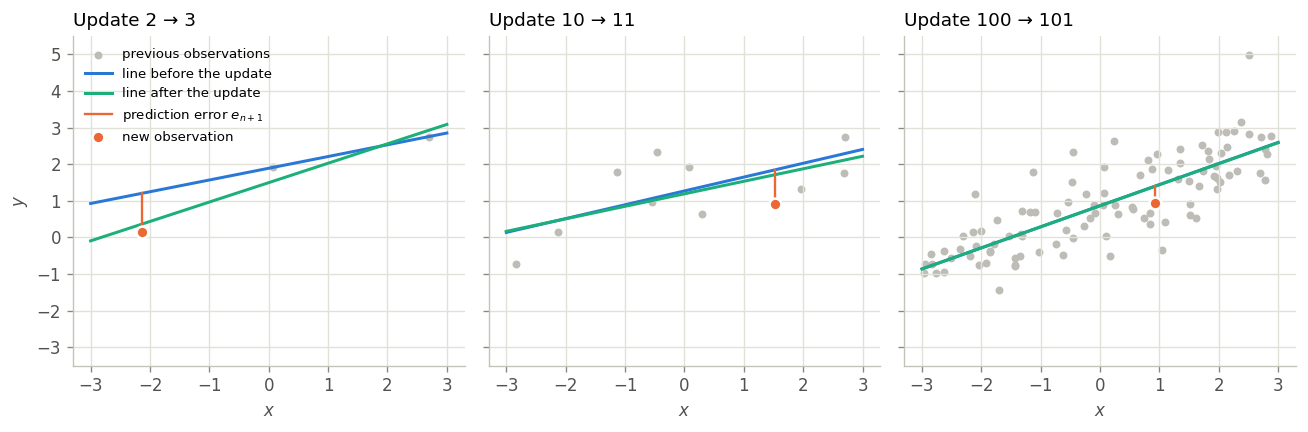

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.7), sharey=True)
grid = np.array([-3.0, 3.0])
for ax, n in zip(axes, [2, 10, 100]):
    before, after = path[n - 1], path[n]           # theta_n and theta_{n+1}
    x_new, y_new = x_values[n], y[n]               # the (n+1)-th observation
    y_pred = before[0] + before[1] * x_new
    ax.scatter(x_values[:n], y[:n], s=14, color=POINTS, label="previous observations")
    ax.plot(grid, before[0] + before[1] * grid, color=BLUE, label="line before the update")
    ax.plot(grid, after[0] + after[1] * grid, color=AQUA, label="line after the update")
    ax.plot([x_new, x_new], [y_pred, y_new], color=ORANGE, lw=1.4, label="prediction error $e_{n+1}$")
    ax.scatter([x_new], [y_new], s=50, color=ORANGE, edgecolor="white", linewidth=1.5, zorder=3,
               label="new observation")
    ax.set(title=f"Update {n} → {n + 1}", xlabel="$x$", ylim=(-3.5, 5.5))
axes[0].set_ylabel("$y$")
axes[0].legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

Early on, a single observation moves the line considerably. After a hundred observations, a similar prediction error hardly changes the line anymore, because the gain vector has become small: the entries of $\mathbf{A}^{-1}$ shrink as more data arrive, and the estimate becomes more certain.

**Check: does the recursion reproduce the direct solution?** The derivation promises that the recursion gives exactly the direct least squares solution after every single update, not only approximately at the end. We therefore compare the stored path with the refits from Section 1. The differences should be of the size of floating-point rounding errors, i.e. around $10^{-15}$ for coefficients of order one.

largest difference over all 200 updates: 9.4e-16


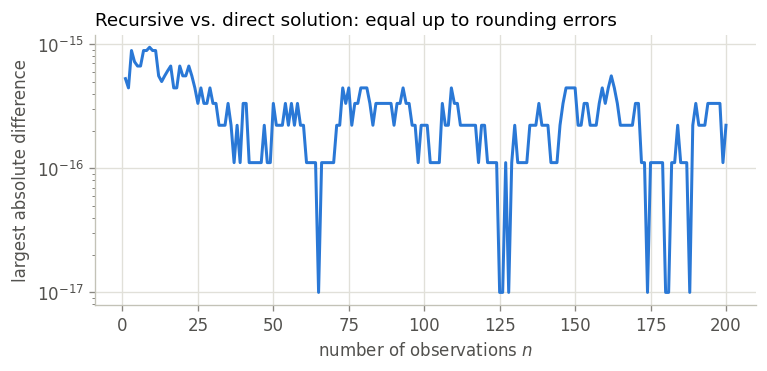

In [8]:
difference = np.abs(path - refits).max(axis=1)
print(f"largest difference over all {n_obs} updates: {difference.max():.1e}")

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.semilogy(np.arange(1, n_obs + 1), np.maximum(difference, 1e-17), color=BLUE)
ax.set(xlabel="number of observations $n$", ylabel="largest absolute difference",
       title="Recursive vs. direct solution: equal up to rounding errors")
fig.tight_layout()
plt.show()

## 3. The Initialization and the Role of $\rho$

The recursion needs a starting point. Before any data have arrived, the natural choice would be $\mathbf{A}_0=\mathbf{0}$ (there is no information yet), but a zero matrix has no inverse. The direct solution has the same problem as long as there are fewer observations than coefficients. A single point does not determine a line, since infinitely many lines pass through it, and mathematically this shows up as a singular matrix $\mathbf{X}^T\mathbf{X}$:

In [9]:
X_one, y_one = X[:1], y[:1]        # a single observation, but two coefficients
print("rank of X^T X:", np.linalg.matrix_rank(X_one.T @ X_one), "(2 would be needed)")
try:
    batch_solution(X_one, y_one, rho=0.0)
except np.linalg.LinAlgError as error:
    print("without regularization:", error)
print("with rho = 0.01:       ", batch_solution(X_one, y_one, rho=0.01))

rank of X^T X: 1 (2 would be needed)
without regularization: Singular matrix
with rho = 0.01:        [1.90168398 0.13488597]


The regularization term $\rho\mathbf{I}$ solves both problems: $\mathbf{A}_0=\rho\mathbf{I}$ is invertible with $\mathbf{A}_0^{-1}=\rho^{-1}\mathbf{I}$, and the direct solution exists from the very first observation. The price is a small bias, since $\rho$ acts like a mild preference for coefficients close to zero. Its influence fades as more observations arrive, because the data term $\mathbf{X}_n^T\mathbf{X}_n$ keeps growing while $\rho\mathbf{I}$ stays the same.

How should we choose $\rho$? The left plot below shows that a large $\rho$ holds the first estimates back towards zero. The right plot shows the opposite end: with an extremely small $\rho$, the initial matrix $\mathbf{A}_0^{-1}=\rho^{-1}\mathbf{I}$ contains huge numbers, the rounding errors of the first updates no longer vanish, and the recursion drifts away from the direct solution. For inputs of order one, values between about $10^{-3}$ and $1$ are a reasonable choice.

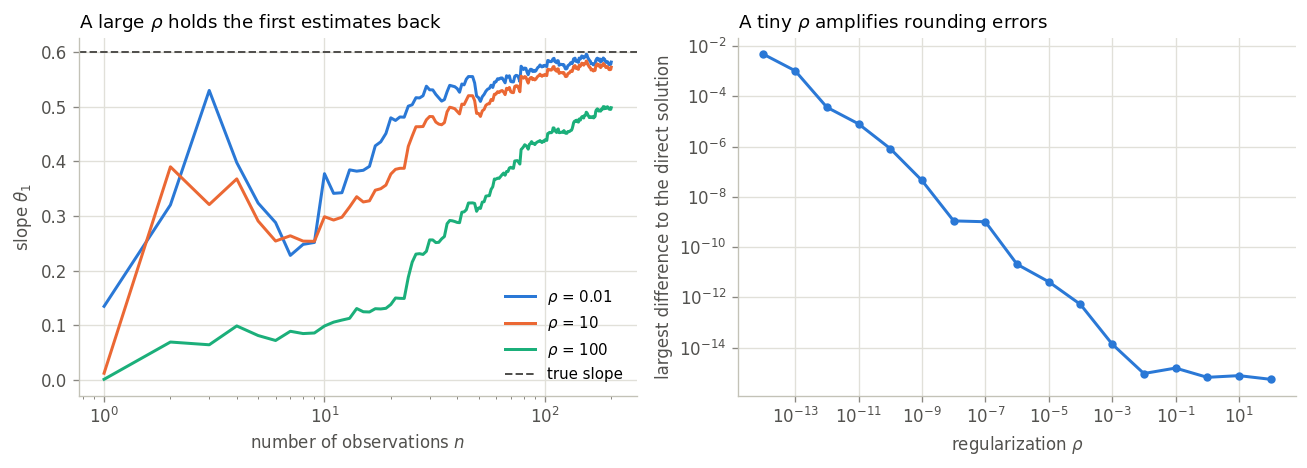

In [10]:
def run_rls(X, y, rho):
    """Process all observations one at a time; return the coefficients after each update."""
    theta, A_inv = np.zeros(X.shape[1]), np.eye(X.shape[1]) / rho
    path = []
    for x_i, y_i in zip(X, y):
        theta, A_inv = rls_update(theta, A_inv, x_i, y_i)
        path.append(theta)
    return np.array(path)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for rho_i in [0.01, 10.0, 100.0]:
    ax1.plot(n_axis, run_rls(X, y, rho_i)[:, 1], label=rf"$\rho$ = {rho_i:g}")
ax1.axhline(theta_true[1], ls="--", color=INK, lw=1.2, label="true slope")
ax1.set(xscale="log", xlabel="number of observations $n$", ylabel=r"slope $\theta_1$",
        title=r"A large $\rho$ holds the first estimates back")
ax1.legend()

rhos = np.logspace(-14, 2, 17)
deviation = []
for rho_i in rhos:
    direct = np.array([batch_solution(X[:n], y[:n], rho=rho_i) for n in range(2, n_obs + 1)])
    deviation.append(np.abs(run_rls(X, y, rho_i)[1:] - direct).max())
ax2.loglog(rhos, deviation, "o-", color=BLUE, markersize=4)
ax2.set(xlabel=r"regularization $\rho$", ylabel="largest difference to the direct solution",
        title=r"A tiny $\rho$ amplifies rounding errors")
fig.tight_layout()
plt.show()

## 4. Weighting Observations

So far, every observation counts equally. In practice, some observations are more reliable than others. Suppose that our data come from two sensors: a precise one with noise standard deviation $\sigma=0.3$ and a cheap one with $\sigma=3$. Weighted least squares assigns each observation a weight $w_i$, and a common choice is the inverse noise variance $w_i=1/\sigma_i^2$, so that precise observations count much more.

According to the blog post, the weight $w_{n+1}$ of the new observation only changes the gain vector:

$$\boldsymbol{\delta}_{n+1} = \frac{w_{n+1}\mathbf{A}_n^{-1}\mathbf{x}_{n+1}}{1+w_{n+1}\mathbf{x}_{n+1}^T\mathbf{A}_n^{-1}\mathbf{x}_{n+1}} .$$

In [11]:
def rls_update(theta, A_inv, x, y, w=1.0):
    """One recursive least squares update with observation weight w (no forgetting)."""
    e = y - x @ theta
    delta = w * A_inv @ x / (1.0 + w * x @ A_inv @ x)   # the only line that changes
    theta = theta + delta * e
    A_inv = A_inv - np.outer(delta, x @ A_inv)
    return theta, A_inv

The next cell generates data from both sensors and runs the recursion with and without weights. Since a single data set can be lucky or unlucky, we also repeat the comparison on $50$ independent data sets and average the distance between the estimated and the true coefficients.

In [12]:
def two_sensor_data(n, rng):
    """Observations of y = 1 + 0.6 x from a precise (sigma = 0.3) and a noisy (sigma = 3) sensor."""
    x = rng.uniform(-3, 3, n)
    sigma = np.where(rng.random(n) < 0.5, 0.3, 3.0)      # which sensor measured each point
    y = 1.0 + 0.6 * x + rng.normal(0, sigma)
    return np.column_stack([np.ones(n), x]), y, sigma

def error_path(X, y, w, rho=0.01):
    """Distance between the recursive estimate and the true coefficients after each update."""
    theta, A_inv = np.zeros(2), np.eye(2) / rho
    errors = []
    for x_i, y_i, w_i in zip(X, y, w):
        theta, A_inv = rls_update(theta, A_inv, x_i, y_i, w_i)
        errors.append(np.linalg.norm(theta - theta_true))
    return np.array(errors), theta

rng = np.random.default_rng(2)
X_s, y_s, sigma = two_sensor_data(300, rng)
n_show = 40                                             # the left plot shows the first 40 observations
_, theta_weighted = error_path(X_s[:n_show], y_s[:n_show], 1 / sigma[:n_show]**2)
_, theta_unweighted = error_path(X_s[:n_show], y_s[:n_show], np.ones(n_show))

data_sets = [two_sensor_data(300, rng) for _ in range(50)]
mean_error_weighted = np.mean([error_path(Xr, yr, 1 / sr**2)[0] for Xr, yr, sr in data_sets], axis=0)
mean_error_unweighted = np.mean([error_path(Xr, yr, np.ones(300))[0] for Xr, yr, sr in data_sets], axis=0)

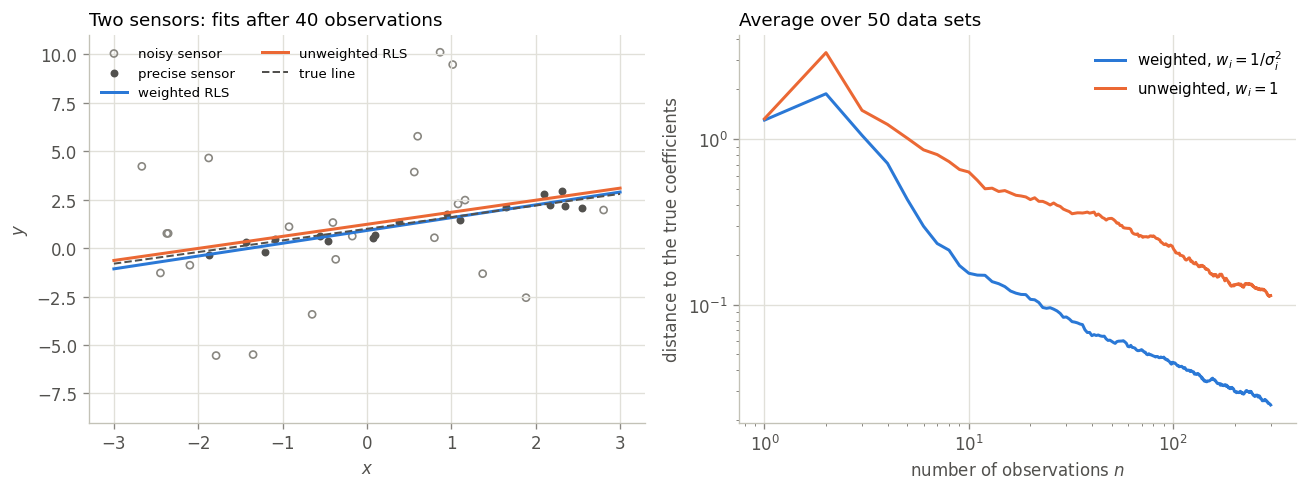

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
precise = sigma[:n_show] < 1
x_show, y_show = X_s[:n_show, 1], y_s[:n_show]
ax1.scatter(x_show[~precise], y_show[~precise], s=18, facecolors="none", edgecolors=MUTED, label="noisy sensor")
ax1.scatter(x_show[precise], y_show[precise], s=14, color=INK, label="precise sensor")
grid = np.array([-3.0, 3.0])
ax1.plot(grid, theta_weighted[0] + theta_weighted[1] * grid, color=BLUE, label="weighted RLS")
ax1.plot(grid, theta_unweighted[0] + theta_unweighted[1] * grid, color=ORANGE, label="unweighted RLS")
ax1.plot(grid, 1.0 + 0.6 * grid, "--", color=INK, lw=1.2, label="true line")
ax1.set(xlabel="$x$", ylabel="$y$", ylim=(-9, 11), title=f"Two sensors: fits after {n_show} observations")
ax1.legend(loc="upper left", fontsize=8, ncol=2)

n_axis_s = np.arange(1, 301)
ax2.loglog(n_axis_s, mean_error_weighted, color=BLUE, label=r"weighted, $w_i = 1/\sigma_i^2$")
ax2.loglog(n_axis_s, mean_error_unweighted, color=ORANGE, label=r"unweighted, $w_i = 1$")
ax2.set(xlabel="number of observations $n$", ylabel="distance to the true coefficients",
        title="Average over 50 data sets")
ax2.legend()
fig.tight_layout()
plt.show()

The weighted estimate is closer to the true line, and on average it reaches a given accuracy with far fewer observations. As before, we check that the weighted recursion reproduces the direct weighted solution after every update:

In [14]:
theta, A_inv, worst = np.zeros(2), np.eye(2) / rho, 0.0
w_s = 1 / sigma**2
for n, (x_i, y_i, w_i) in enumerate(zip(X_s, y_s, w_s), start=1):
    theta, A_inv = rls_update(theta, A_inv, x_i, y_i, w_i)
    worst = max(worst, np.abs(theta - batch_solution(X_s[:n], y_s[:n], w_s[:n], rho)).max())
print(f"largest difference to the direct weighted solution: {worst:.1e}")

largest difference to the direct weighted solution: 3.4e-14


## 5. Forgetting Old Observations

Up to now, every observation keeps its weight forever. This is exactly right if the relationship between $x$ and $y$ never changes. In many applications, however, it does change (a sensor ages, or a process is adjusted), and old observations then describe a situation that no longer exists. Exponential forgetting multiplies the weights of all previous observations by a factor $0<\lambda\leq1$ in every update. An observation that is $a$ updates old therefore has the weight $\lambda^a$ (left plot below). These weights add up to about $1/(1-\lambda)$, which gives a useful rule of thumb for the memory of the estimator: with $\lambda=0.98$, it mainly relies on the last $50$ observations.

With forgetting, the blog post gives

$$
\begin{aligned}
\boldsymbol{\delta}_{n+1} &= \frac{w_{n+1}\mathbf{A}_n^{-1}\mathbf{x}_{n+1}}{\lambda_n+w_{n+1}\mathbf{x}_{n+1}^T\mathbf{A}_n^{-1}\mathbf{x}_{n+1}}, \\
\mathbf{A}_{n+1}^{-1} &= \frac{1}{\lambda_n}\Big(\mathbf{A}_n^{-1}-\boldsymbol{\delta}_{n+1}\mathbf{x}_{n+1}^T\mathbf{A}_n^{-1}\Big),
\end{aligned}
$$

while $e_{n+1}$ and $\boldsymbol{\theta}_{n+1}$ are computed as before. Here, $\lambda_n=\lambda$ for all updates except the very first one, which uses $\lambda_0=1$: there is nothing to forget yet, and the initial regularization should start at its full value $\rho$.

In [15]:
def rls_update(theta, A_inv, x, y, w=1.0, lam_n=1.0):
    """One weighted recursive least squares update with forgetting factor lam_n."""
    e = y - x @ theta
    delta = w * A_inv @ x / (lam_n + w * x @ A_inv @ x)
    theta = theta + delta * e
    A_inv = (A_inv - np.outer(delta, x @ A_inv)) / lam_n
    return theta, A_inv

As an example, the true intercept and slope change abruptly after $400$ of $800$ observations. We run the recursion with three different forgetting factors:

In [16]:
rng = np.random.default_rng(3)
n_drift = 800
x_drift = rng.uniform(-3, 3, n_drift)
X_drift = np.column_stack([np.ones(n_drift), x_drift])
before_change = np.arange(n_drift)[:, None] < 400
theta_drift = np.where(before_change, [1.0, 0.6], [-0.5, -0.4])     # true coefficients over time
y_drift = np.sum(X_drift * theta_drift, axis=1) + rng.normal(0, 0.5, n_drift)

def run_rls_forgetting(X, y, lam, rho=0.01):
    """Process all observations one at a time with forgetting factor lam; return all coefficients."""
    theta, A_inv = np.zeros(X.shape[1]), np.eye(X.shape[1]) / rho
    path = []
    for n, (x_i, y_i) in enumerate(zip(X, y)):
        lam_n = 1.0 if n == 0 else lam            # no forgetting in the very first update
        theta, A_inv = rls_update(theta, A_inv, x_i, y_i, 1.0, lam_n)
        path.append(theta)
    return np.array(path)

paths = {lam: run_rls_forgetting(X_drift, y_drift, lam) for lam in [1.0, 0.98, 0.9]}

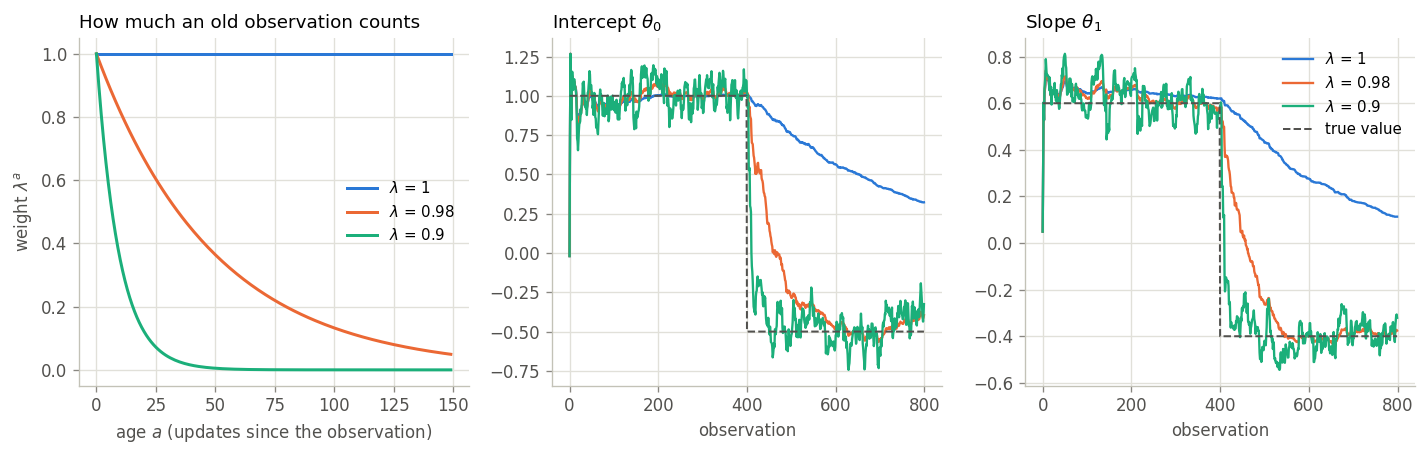

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.9))
ages = np.arange(150)
for lam in paths:
    axes[0].plot(ages, lam ** ages, label=rf"$\lambda$ = {lam:g}")
axes[0].set(xlabel="age $a$ (updates since the observation)", ylabel=r"weight $\lambda^a$",
            title="How much an old observation counts")
axes[0].legend()
for ax, j, name in [(axes[1], 0, r"Intercept $\theta_0$"), (axes[2], 1, r"Slope $\theta_1$")]:
    for lam, path_lam in paths.items():
        ax.plot(path_lam[:, j], lw=1.4, label=rf"$\lambda$ = {lam:g}")
    ax.plot(theta_drift[:, j], "--", color=INK, lw=1.2, label="true value")
    ax.set(xlabel="observation", title=name)
axes[2].legend()
fig.tight_layout()
plt.show()

Without forgetting ($\lambda=1$), the estimate after the change is an average over both situations and approaches the new values only very slowly. With $\lambda=0.98$, the estimate follows the change within about a hundred observations. With $\lambda=0.9$, it reacts even faster but is noticeably noisier, because it effectively uses only the last ten observations. Choosing $\lambda$ is therefore a trade-off between fast adaptation and low noise.

**Check: which problem does the recursion solve now?** With forgetting, the recursion should reproduce the direct weighted solution in which an observation of age $a$ has the weight $\lambda^a$. There is one subtlety, which the blog post discusses: the recursion forgets the initial regularization as well, because $\mathbf{A}_0=\rho\mathbf{I}$ is divided by $\lambda$ in every update, just like the old observations. After $n$ observations, the effective regularization is therefore $\rho\lambda^{n-1}$. The comparison below confirms this: the direct solution with the decayed $\rho$ agrees with the recursion up to rounding errors, whereas a fixed $\rho$ leads to small but clear differences.

In [18]:
lam = 0.98
path_lam = paths[lam]
diff_decayed = diff_fixed = 0.0
for n in range(1, n_drift + 1):
    weights = lam ** np.arange(n - 1, -1, -1)            # lambda^age for observations 1, ..., n
    decayed = batch_solution(X_drift[:n], y_drift[:n], weights, rho * lam ** (n - 1))
    fixed = batch_solution(X_drift[:n], y_drift[:n], weights, rho)
    diff_decayed = max(diff_decayed, np.abs(path_lam[n - 1] - decayed).max())
    diff_fixed = max(diff_fixed, np.abs(path_lam[n - 1] - fixed).max())
print(f"direct solution with decayed rho: largest difference {diff_decayed:.1e}")
print(f"direct solution with fixed rho:   largest difference {diff_fixed:.1e}")

direct solution with decayed rho: largest difference 2.4e-15
direct solution with fixed rho:   largest difference 1.7e-03


## 6. Rounding Errors and the Symmetry of $\mathbf{A}^{-1}$

The matrix $\mathbf{A}_n$ is symmetric, and so is its inverse. In the update, we compute both $\mathbf{A}_n^{-1}\mathbf{x}_{n+1}$ (for the gain) and $\mathbf{x}_{n+1}^T\mathbf{A}_n^{-1}$ (for the new inverse). For a symmetric matrix, these two products contain the same numbers, so it is tempting to compute only one of them and reuse it. In exact arithmetic, this changes nothing. In floating-point arithmetic, however, the computed $\mathbf{A}^{-1}$ is never perfectly symmetric, and with forgetting this becomes a problem. Every update divides by $\lambda<1$, and in the variant with reuse, the tiny asymmetric part of the rounding errors is multiplied by $1/\lambda$ in every step, without anything that would damp it.

The following experiment runs three variants on a stream whose true coefficients never change, with $\lambda=0.95$: the literal implementation from Section 5, the variant that reuses $\mathbf{A}_n^{-1}\mathbf{x}_{n+1}$, and the same variant with a simple remedy, which replaces $\mathbf{A}^{-1}$ after every update by its symmetric part $\frac{1}{2}\big(\mathbf{A}^{-1}+(\mathbf{A}^{-1})^T\big)$.

In [19]:
def rls_update_reuse(theta, A_inv, x, y, w=1.0, lam_n=1.0, symmetrize=False):
    """Like rls_update, but computes A^{-1} x once and reuses it instead of x^T A^{-1}."""
    e = y - x @ theta
    Ax = A_inv @ x                                   # computed once ...
    delta = w * Ax / (lam_n + w * x @ Ax)
    theta = theta + delta * e
    A_inv = (A_inv - np.outer(delta, Ax)) / lam_n    # ... and reused here
    if symmetrize:
        A_inv = 0.5 * (A_inv + A_inv.T)              # the remedy: keep A^{-1} exactly symmetric
    return theta, A_inv

rng = np.random.default_rng(4)
n_sym, lam = 2000, 0.95
X_sym = np.column_stack([np.ones(n_sym), rng.uniform(-3, 3, n_sym)])
y_sym = X_sym @ theta_true + rng.normal(0, 0.5, n_sym)

def run_variant(variant):
    theta, A_inv = np.zeros(2), np.eye(2) / rho
    asymmetry, slopes = [], []
    for n, (x_i, y_i) in enumerate(zip(X_sym, y_sym)):
        lam_n = 1.0 if n == 0 else lam
        if variant == "literal":
            theta, A_inv = rls_update(theta, A_inv, x_i, y_i, 1.0, lam_n)
        else:
            theta, A_inv = rls_update_reuse(theta, A_inv, x_i, y_i, 1.0, lam_n,
                                            symmetrize=(variant == "reuse + symmetrize"))
        asymmetry.append(np.abs(A_inv - A_inv.T).max() / np.abs(A_inv).max())
        slopes.append(theta[1])
    return np.array(asymmetry), np.array(slopes)

results = {variant: run_variant(variant) for variant in ["literal", "reuse", "reuse + symmetrize"]}

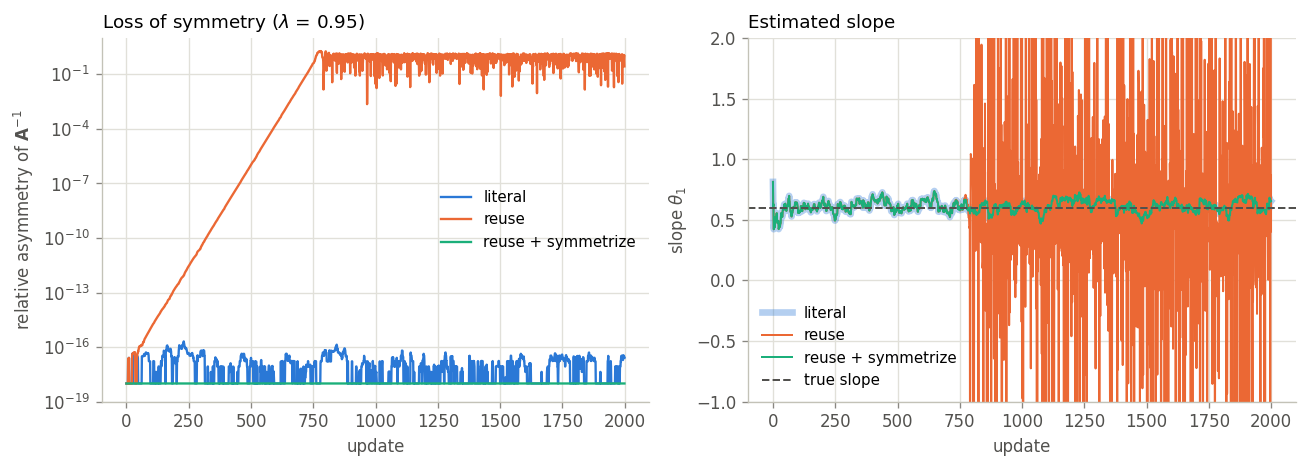

reuse: asymmetry exceeds 0.1 % of A^-1 after 634 updates


In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for name, (asymmetry, slopes) in results.items():
    ax1.semilogy(np.maximum(asymmetry, 1e-18), lw=1.4, label=name)
    if name == "literal":     # drawn wide and light, because the symmetrized variant lies on top of it
        ax2.plot(slopes, lw=4, alpha=0.35, label=name)
    else:
        ax2.plot(slopes, lw=1.2, label=name)
ax1.set(xlabel="update", ylabel=r"relative asymmetry of $\mathbf{A}^{-1}$", ylim=(1e-19, 10),
        title=r"Loss of symmetry ($\lambda$ = 0.95)")
ax1.legend()
ax2.axhline(theta_true[1], ls="--", color=INK, lw=1.2, label="true slope")
ax2.set(xlabel="update", ylabel=r"slope $\theta_1$", ylim=(-1, 2), title="Estimated slope")
ax2.legend(loc="lower left")
fig.tight_layout()
plt.show()
first_bad = np.argmax(results["reuse"][0] > 1e-3)
print(f"reuse: asymmetry exceeds 0.1 % of A^-1 after {first_bad} updates")

The literal implementation stays symmetric up to rounding errors (at about $10^{-16}$). The variant with reuse loses its symmetry exponentially fast and, after several hundred updates, produces useless estimates. With symmetrization, the asymmetry is exactly zero (it is drawn at the bottom of the left plot), and the estimates are as good as those of the literal implementation. The class in Section 9 reuses products for efficiency and therefore symmetrizes $\mathbf{A}^{-1}$ after every update; this costs almost nothing.

## 7. Processing Batches of Observations

Observations often arrive in groups, for instance when a sensor delivers several measurements at once, or we may simply want to process a large data set faster. For a batch of $\mu$ observations, the blog post derives

$$
\begin{aligned}
\mathbf{e}_\mu &= \mathbf{y}_\mu-\mathbf{X}_\mu\boldsymbol{\theta}_n, \\
\boldsymbol{\Delta}_\mu &= \mathbf{A}_n^{-1}\mathbf{X}_\mu^T\big(\lambda_n\mathbf{W}_\mu^{-1}+\mathbf{X}_\mu\mathbf{A}_n^{-1}\mathbf{X}_\mu^T\big)^{-1}, \\
\boldsymbol{\theta}_{n+\mu} &= \boldsymbol{\theta}_n+\boldsymbol{\Delta}_\mu\mathbf{e}_\mu, \\
\mathbf{A}_{n+\mu}^{-1} &= \frac{1}{\lambda_n}\Big(\mathbf{A}_n^{-1}-\boldsymbol{\Delta}_\mu\mathbf{X}_\mu\mathbf{A}_n^{-1}\Big).
\end{aligned}
$$

The structure is the same as before, but the prediction errors now form a vector $\mathbf{e}_\mu$, the gain becomes a $k\times\mu$ matrix $\boldsymbol{\Delta}_\mu$, and the scalar denominator turns into a $\mu\times\mu$ matrix that has to be inverted. $\mathbf{W}_\mu$ is the diagonal matrix with the $\mu$ weights of the batch. Again, the code is a direct translation:

In [21]:
def rls_batch_update(theta, A_inv, X_mu, y_mu, w_mu, lam_n=1.0):
    """One recursive least squares update with a batch of observations (the rows of X_mu)."""
    e_mu = y_mu - X_mu @ theta                                    # prediction errors
    S = lam_n * np.diag(1.0 / w_mu) + X_mu @ A_inv @ X_mu.T      # the mu x mu matrix
    Delta_mu = A_inv @ X_mu.T @ np.linalg.inv(S)                  # gain matrix, shape (k, mu)
    theta = theta + Delta_mu @ e_mu
    A_inv = (A_inv - Delta_mu @ X_mu @ A_inv) / lam_n
    return theta, A_inv

**Check: batches give the same result as single observations.** Without forgetting, it should not matter whether we feed the observations one at a time or in batches. We process the stream from Section 1 in batches of $\mu=10$ and compare the coefficients after each batch with the direct solution:

In [22]:
mu = 10
theta, A_inv, worst = np.zeros(2), np.eye(2) / rho, 0.0
for start in range(0, n_obs, mu):
    X_mu, y_mu = X[start:start + mu], y[start:start + mu]
    theta, A_inv = rls_batch_update(theta, A_inv, X_mu, y_mu, np.ones(len(X_mu)))
    worst = max(worst, np.abs(theta - refits[start + len(X_mu) - 1]).max())
print(f"largest difference to the direct solution after each batch: {worst:.1e}")

largest difference to the direct solution after each batch: 5.1e-11


The differences are somewhat larger than for single observations, because the first batch starts from the large matrix $\mathbf{A}_0^{-1}=100\,\mathbf{I}$ and the $\mu\times\mu$ matrix is inverted explicitly. They are still far too small to matter in practice.

**Forgetting in batch mode.** With $\lambda<1$, the forgetting factor is applied once per batch. All observations of a batch therefore have the same age, and the memory is counted in batches rather than in observations. A batch recursion with $\lambda$ does not reproduce the single-observation recursion with the same $\lambda$. For a similar memory, we can use $\lambda^\mu$ per batch instead (for example $0.98^{10}\approx0.82$ for batches of ten).

**Why batches? Speed.** Every call of the update involves a few matrix operations, and in Python, the overhead of a call is often larger than the arithmetic itself. Processing many observations per call therefore saves time. On the other hand, the $\mu\times\mu$ matrix in the gain has to be inverted, and this cost grows like $\mu^3$. The next experiment measures how long it takes to process $20{,}000$ observations with $k=10$ features for different batch sizes. The exact times depend on the computer that runs the notebook.

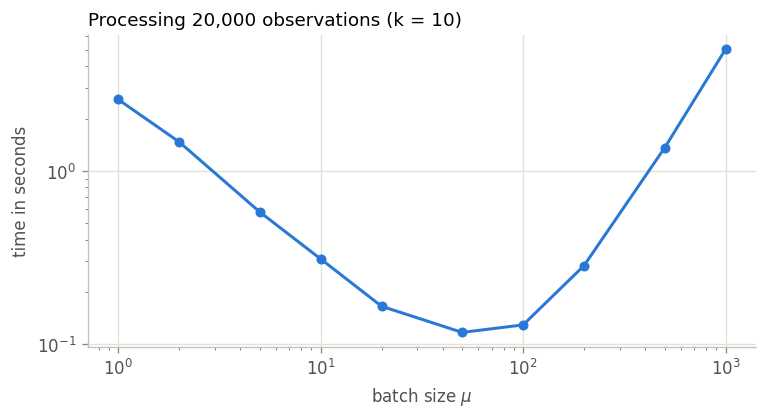

fastest batch size in this run: 50 (0.116 s, single observations: 2.578 s)


In [23]:
rng = np.random.default_rng(5)
n_big, k_big = 20_000, 10
X_big = rng.normal(size=(n_big, k_big))
y_big = X_big @ rng.normal(size=k_big) + rng.normal(0, 0.1, n_big)

batch_sizes = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
seconds = []
for mu in batch_sizes:
    theta, A_inv = np.zeros(k_big), np.eye(k_big)
    start_time = time.perf_counter()
    for start in range(0, n_big, mu):
        X_mu, y_mu = X_big[start:start + mu], y_big[start:start + mu]
        theta, A_inv = rls_batch_update(theta, A_inv, X_mu, y_mu, np.ones(len(X_mu)))
    seconds.append(time.perf_counter() - start_time)

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.loglog(batch_sizes, seconds, "o-", color=BLUE, markersize=5)
ax.set(xlabel=r"batch size $\mu$", ylabel="time in seconds", title="Processing 20,000 observations (k = 10)")
fig.tight_layout()
plt.show()
fastest = batch_sizes[int(np.argmin(seconds))]
print(f"fastest batch size in this run: {fastest} ({min(seconds):.3f} s, single observations: {seconds[0]:.3f} s)")

Moderate batch sizes are fastest. For very large batches, the $\mu\times\mu$ matrix dominates and the recursion becomes slower again.

## 8. Several Outputs at Once

Sometimes we want to predict several quantities from the same inputs, for example the horizontal and the vertical position of an object. In the blog post, this only requires replacing the targets by a matrix $\mathbf{Y}_\mu$ and the coefficient vector by a matrix $\boldsymbol{\Theta}_n$, each with one column per output. The gain and the update of $\mathbf{A}^{-1}$ do not depend on the targets at all. All outputs share them, so $m$ outputs cost hardly more than one.

For a single new observation, $\mathbf{Y}_\mu$ is a row vector with one target per output, and the update becomes

$$
\begin{aligned}
\mathbf{E}_\mu &= \mathbf{Y}_\mu-\mathbf{x}_{n+1}^T\boldsymbol{\Theta}_n, \\
\boldsymbol{\Theta}_{n+1} &= \boldsymbol{\Theta}_n+\boldsymbol{\delta}_{n+1}\mathbf{E}_\mu,
\end{aligned}
$$

while $\boldsymbol{\delta}_{n+1}$ and $\mathbf{A}_{n+1}^{-1}$ are computed exactly as in Section 5. The row vector $\mathbf{E}_\mu$ contains the prediction errors of all outputs, and the coefficient update is an outer product: every column of $\boldsymbol{\Theta}$ is corrected in the same direction $\boldsymbol{\delta}_{n+1}$, scaled by the prediction error of its own output. In the code, only these two lines change:

In [24]:
def rls_update_multi(Theta, A_inv, x, y, w=1.0, lam_n=1.0):
    """Like rls_update, but for m outputs: y holds one target per output, Theta has m columns."""
    e = y - x @ Theta                                     # prediction errors of all outputs (length m)
    delta = w * A_inv @ x / (lam_n + w * x @ A_inv @ x)   # the same gain as before
    Theta = Theta + np.outer(delta, e)                    # Theta_{n+1} = Theta_n + delta_{n+1} E_mu
    A_inv = (A_inv - np.outer(delta, x @ A_inv)) / lam_n  # the same update as before
    return Theta, A_inv

For batches, the blog post uses $\mathbf{E}_\mu=\mathbf{Y}_\mu-\mathbf{X}_\mu\boldsymbol{\Theta}_n$ and $\boldsymbol{\Theta}_{n+\mu}=\boldsymbol{\Theta}_n+\boldsymbol{\Delta}_\mu\mathbf{E}_\mu$ with a $\mu\times m$ matrix $\mathbf{Y}_\mu$. Here, no new code is needed: `rls_batch_update` from Section 7 consists of matrix products only and works unchanged when `theta` and `y_mu` are matrices.

As an example, we learn a closed curve from noisy points. Each observation consists of a parameter $t$ (think of the time on a circular track) and the noisy position $(u, v)$ of the corresponding point on the curve. The inputs are $\mathbf{x}=(1,\cos t,\sin t,\cos 2t,\sin 2t,\ldots,\cos 4t,\sin 4t)^T$, so that $k=9$, and the two outputs are $u$ and $v$. Although the curve is far from a straight line, the model is linear in its coefficients, and that is all that least squares needs. The observations arrive one at a time, and we process them with `rls_update_multi`.

In [25]:
def fourier_features(t, order=4):
    """Input vectors (1, cos t, sin t, ..., cos(order t), sin(order t)) as rows."""
    columns = [np.ones_like(t)]
    for j in range(1, order + 1):
        columns += [np.cos(j * t), np.sin(j * t)]
    return np.column_stack(columns)

def heart(t):
    """Points (u, v) of a heart-shaped closed curve, one row per parameter value."""
    u = 12 * np.sin(t) - 4 * np.sin(3 * t)
    v = 13 * np.cos(t) - 5 * np.cos(2 * t) - 2 * np.cos(3 * t) - np.cos(4 * t)
    return np.column_stack([u, v])

rng = np.random.default_rng(6)
n_curve = 500
t_obs = rng.uniform(0, 2 * np.pi, n_curve)
X_curve = fourier_features(t_obs)                            # k = 9 inputs
Y_curve = heart(t_obs) + rng.normal(0, 1.0, (n_curve, 2))    # m = 2 noisy outputs

Theta, A_inv = np.zeros((9, 2)), np.eye(9) / rho             # one column of coefficients per output
snapshots = {}
for n, (x_i, y_i) in enumerate(zip(X_curve, Y_curve), start=1):
    Theta, A_inv = rls_update_multi(Theta, A_inv, x_i, y_i)  # y_i holds both coordinates (u, v)
    snapshots[n] = Theta.copy()

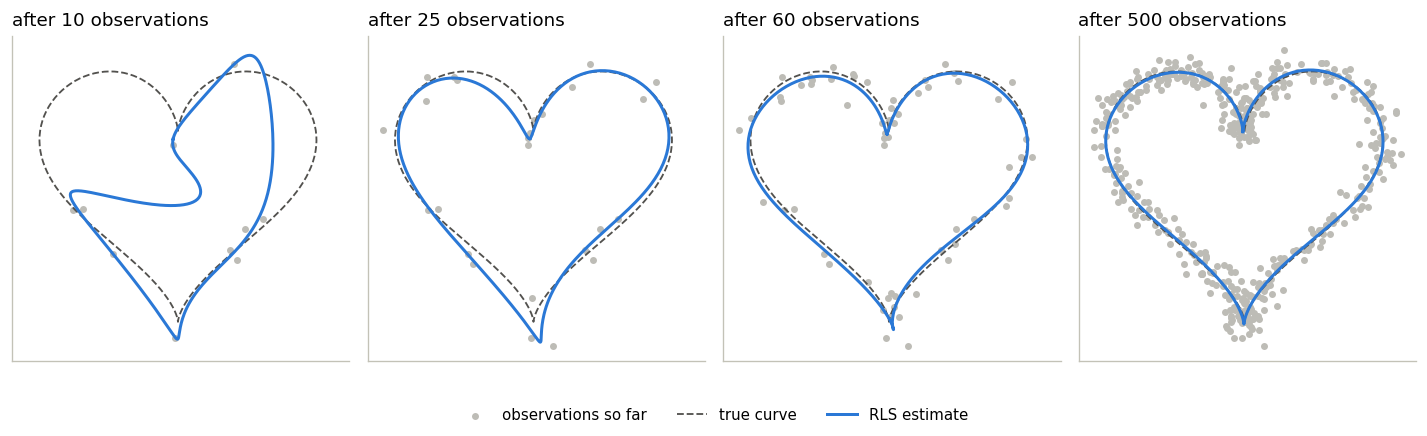

In [26]:
t_grid = np.linspace(0, 2 * np.pi, 400)
fig, axes = plt.subplots(1, 4, figsize=(12, 3.6), sharex=True, sharey=True)
for ax, n in zip(axes, [10, 25, 60, 500]):
    fitted = fourier_features(t_grid) @ snapshots[n]
    ax.scatter(*Y_curve[:n].T, s=10, color=POINTS, label="observations so far")
    ax.plot(*heart(t_grid).T, "--", color=INK, lw=1.1, label="true curve")
    ax.plot(*fitted.T, color=BLUE, label="RLS estimate")
    ax.set(title=f"after {n} observations", aspect="equal", xticks=[], yticks=[])
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3)
fig.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

**Check: several outputs are just several single-output problems.** Because the outputs share the inputs, the joint fit must agree with $m$ separate fits, one per output. It must also agree with the batch version from Section 7, which processes the same data in batches of five, and with the direct solution:

In [27]:
separate = []
for j in range(2):                                           # fit each output on its own
    theta_j, A_inv_j = np.zeros(9), np.eye(9) / rho
    for x_i, y_i in zip(X_curve, Y_curve[:, j]):
        theta_j, A_inv_j = rls_update(theta_j, A_inv_j, x_i, y_i)
    separate.append(theta_j)

Theta_batch, A_inv_batch = np.zeros((9, 2)), np.eye(9) / rho  # the same data in batches of 5
for start in range(0, n_curve, 5):
    Theta_batch, A_inv_batch = rls_batch_update(Theta_batch, A_inv_batch, X_curve[start:start + 5],
                                                Y_curve[start:start + 5], np.ones(5))

print(f"joint fit vs. separate fits:     {np.abs(Theta - np.column_stack(separate)).max():.1e}")
print(f"single observations vs. batches: {np.abs(Theta - Theta_batch).max():.1e}")
print(f"joint fit vs. direct solution:   {np.abs(Theta - batch_solution(X_curve, Y_curve, rho=rho)).max():.1e}")

joint fit vs. separate fits:     0.0e+00
single observations vs. batches: 4.2e-13
joint fit vs. direct solution:   5.3e-15


## 9. Putting It All Together: the `WeightedRLS` Class

We now have all ingredients, and the class below combines them:

- the initialization $\boldsymbol{\Theta}_0=\mathbf{0}$ and $\mathbf{A}_0^{-1}=\rho^{-1}\mathbf{I}$ (Section 3),
- positive observation weights (Section 4),
- exponential forgetting with $\lambda_0=1$ for the first update (Section 5),
- batches of any size, including single observations (Section 7), and
- one or several outputs (Section 8).

Compared with `rls_batch_update`, two implementation details differ. First, the product $\mathbf{X}_\mu\mathbf{A}_n^{-1}$ is computed once and reused, and the gain is obtained with `np.linalg.solve` instead of an explicit matrix inverse (the result is the same, but solving is cheaper and more accurate). Since this relies on the symmetry of $\mathbf{A}^{-1}$, the class symmetrizes it after every update, as discussed in Section 6. Second, the class checks its inputs, so that a wrongly shaped array or a non-positive weight raises an error instead of silently corrupting the estimate. The same code is available as the module [`weighted_rls.py`](https://markusthill.github.io/assets/code/2026-09-23-derivation-of-a-weighted-recursive-least-squares-estimator/weighted_rls.py).

In [28]:
from typing import Optional, Tuple

import numpy as np
from numpy.typing import ArrayLike, NDArray


class WeightedRLS:
    """Weighted recursive least squares with exponential forgetting.

    The class fits the linear model ``Y ≈ X @ theta`` and refines the
    coefficients whenever new observations arrive, using the batch equations
    of the blog post. Each call of :meth:`update` processes a batch of
    ``mu >= 1`` observations (the rows of ``X``) with optional positive
    weights, for one or several outputs (the columns of ``Y``).

    Parameters
    ----------
    n_features : int
        Number of entries ``k`` of an input vector. If the model needs an
        intercept, add a column of ones to the inputs.
    n_outputs : int, default=1
        Number of outputs ``m``.
    forgetting : float, default=1.0
        Forgetting factor ``lambda`` in (0, 1]. With 1, all observations keep
        their weight. With a smaller value, the weights of all earlier batches
        are multiplied by ``lambda`` in every update except the first one.
    ridge : float, default=1.0
        Initial regularization ``rho > 0``, i.e. ``A_0 = rho * I``. With
        forgetting, it decays together with the old observations.

    Attributes
    ----------
    theta : ndarray of shape (n_features, n_outputs)
        Current coefficients.
    A_inv : ndarray of shape (n_features, n_features)
        Current inverse of the regularized, weighted normal matrix.
    n_seen : int
        Number of observations processed so far.

    Examples
    --------
    >>> rng = np.random.default_rng(0)
    >>> X = np.column_stack([np.ones(100), rng.uniform(-1, 1, 100)])
    >>> y = X @ [2.0, -1.0] + 0.01 * rng.normal(size=100)
    >>> rls = WeightedRLS(n_features=2, ridge=1e-3)
    >>> errors = rls.fit(X, y, batch_size=10)
    >>> rls.theta.round(2).ravel()
    array([ 2., -1.])
    >>> rls.predict([1.0, 0.5]).round(2)
    array([[1.5]])
    """

    def __init__(self, n_features: int, n_outputs: int = 1,
                 forgetting: float = 1.0, ridge: float = 1.0) -> None:
        if n_features < 1 or n_outputs < 1:
            raise ValueError("n_features and n_outputs must be at least 1")
        if not 0.0 < forgetting <= 1.0:
            raise ValueError("forgetting must be in (0, 1]")
        if not ridge > 0.0:
            raise ValueError("ridge must be positive")
        self.n_features = n_features
        self.n_outputs = n_outputs
        self.forgetting = forgetting
        self.ridge = ridge
        self.reset()

    def reset(self) -> None:
        """Start from scratch: theta = 0 and A_inv = I / ridge."""
        self.theta: NDArray[np.float64] = np.zeros((self.n_features, self.n_outputs))
        self.A_inv: NDArray[np.float64] = np.eye(self.n_features) / self.ridge
        self.n_seen = 0

    def update(self, X: ArrayLike, Y: ArrayLike,
               weights: Optional[ArrayLike] = None) -> NDArray[np.float64]:
        """Learn from one batch of observations.

        Parameters
        ----------
        X : array_like of shape (mu, n_features)
            Input vectors as rows. A 1-D array is a single observation.
        Y : array_like of shape (mu, n_outputs)
            Targets. For a single output, shape (mu,) is accepted as well, and
            for a single observation, shape (n_outputs,) or a scalar.
        weights : array_like of shape (mu,), optional
            Positive observation weights, i.e. the diagonal of W_mu.
            By default, all weights are 1.

        Returns
        -------
        ndarray of shape (mu, n_outputs)
            Prediction errors ``Y - X @ theta``, computed *before* the update.
        """
        X_mu, Y_mu, w_mu = self._check_batch(X, Y, weights)
        lam_n = 1.0 if self.n_seen == 0 else self.forgetting   # lambda_0 = 1

        E_mu = Y_mu - X_mu @ self.theta                          # prediction errors E_mu
        XA = X_mu @ self.A_inv                                   # X_mu A_n^{-1}, shape (mu, k)
        S = lam_n * np.diag(1.0 / w_mu) + XA @ X_mu.T            # lambda_n W_mu^{-1} + X_mu A_n^{-1} X_mu^T
        Delta_mu = np.linalg.solve(S, XA).T                      # gain A_n^{-1} X_mu^T S^{-1}, shape (k, mu)
        self.theta = self.theta + Delta_mu @ E_mu                # Theta_{n+mu} = Theta_n + Delta_mu E_mu
        A_inv = (self.A_inv - Delta_mu @ XA) / lam_n             # A_{n+mu}^{-1}
        self.A_inv = 0.5 * (A_inv + A_inv.T)                     # keep A^{-1} exactly symmetric
        self.n_seen += len(X_mu)
        return E_mu

    def fit(self, X: ArrayLike, Y: ArrayLike, batch_size: int = 1,
            weights: Optional[ArrayLike] = None) -> NDArray[np.float64]:
        """Process a whole data set in consecutive batches of ``batch_size`` rows.

        The fit continues from the current state; call :meth:`reset` first to
        start from scratch. Returns the prediction errors of all rows, each
        computed before its batch was learned.
        """
        X = np.asarray(X, dtype=float)
        Y = np.asarray(Y, dtype=float)
        w = np.ones(len(X)) if weights is None else np.asarray(weights, dtype=float)
        errors = [self.update(X[i:i + batch_size], Y[i:i + batch_size], w[i:i + batch_size])
                  for i in range(0, len(X), batch_size)]
        return np.vstack(errors) if errors else np.empty((0, self.n_outputs))

    def predict(self, X: ArrayLike) -> NDArray[np.float64]:
        """Return the predictions ``X @ theta``, shape (n_samples, n_outputs)."""
        X = np.atleast_2d(np.asarray(X, dtype=float))
        if X.shape[1] != self.n_features:
            raise ValueError(f"X must have {self.n_features} columns")
        return X @ self.theta

    def _check_batch(self, X: ArrayLike, Y: ArrayLike, weights: Optional[ArrayLike]
                     ) -> Tuple[NDArray[np.float64], NDArray[np.float64], NDArray[np.float64]]:
        """Bring a batch into the shapes (mu, k), (mu, m) and (mu,) and validate it."""
        X_mu = np.atleast_2d(np.asarray(X, dtype=float))
        mu = X_mu.shape[0]
        Y_mu = np.asarray(Y, dtype=float)
        if Y_mu.ndim == 0 or (Y_mu.ndim == 1 and self.n_outputs == 1):
            Y_mu = Y_mu.reshape(-1, 1)           # scalar, or the mu targets of a single output
        elif Y_mu.ndim == 1 and mu == 1:
            Y_mu = Y_mu.reshape(1, -1)           # the m targets of a single observation
        w_mu = np.ones(mu) if weights is None else np.asarray(weights, dtype=float).reshape(-1)
        if X_mu.ndim != 2 or X_mu.shape[1] != self.n_features:
            raise ValueError(f"X must have shape (mu, {self.n_features})")
        if Y_mu.shape != (mu, self.n_outputs):
            raise ValueError(f"Y must have shape ({mu}, {self.n_outputs})")
        if w_mu.shape != (mu,) or np.any(w_mu <= 0):
            raise ValueError(f"weights must contain {mu} positive values")
        if not (np.isfinite(X_mu).all() and np.isfinite(Y_mu).all() and np.isfinite(w_mu).all()):
            raise ValueError("the batch must not contain NaN or infinite values")
        return X_mu, Y_mu, w_mu

A short usage example, the same as in the docstring: we fit a line to $100$ observations in batches of ten and predict the value at $x=0.5$.

In [29]:
rng = np.random.default_rng(0)
X_demo = np.column_stack([np.ones(100), rng.uniform(-1, 1, 100)])   # column of ones for the intercept
y_demo = X_demo @ [2.0, -1.0] + 0.01 * rng.normal(size=100)

rls = WeightedRLS(n_features=2, ridge=1e-3)
errors = rls.fit(X_demo, y_demo, batch_size=10)
print("coefficients:", rls.theta.ravel())
print("prediction for x = 0.5:", rls.predict([1.0, 0.5]).item())

coefficients: [ 1.99924865 -1.00062114]
prediction for x = 0.5: 1.4989380750165906


**Final check.** To make sure that all pieces fit together, we compare the class with the direct solution in several configurations: single observations and batches of ten (the last batch is smaller), one and three outputs, unit and random weights, with and without forgetting. With forgetting, the direct solution uses the weights $\lambda^a$, where the age $a$ is now counted in batches, and the decayed regularization $\rho\lambda^{M-1}$ after $M$ batches. The comparison is made after every update.

In [30]:
def direct_solution_with_forgetting(X, Y, w, rho, lam, batch_size):
    """Direct solution of the problem that the recursion solves after processing X in batches."""
    batch_index = np.arange(len(X)) // batch_size
    n_batches = batch_index[-1] + 1
    ages = n_batches - 1 - batch_index                       # ages counted in batches
    return batch_solution(X, Y, w * lam ** ages, rho * lam ** (n_batches - 1))

rng = np.random.default_rng(7)
X_test = np.column_stack([np.ones(103), rng.normal(size=(103, 3))])    # k = 4, 103 rows
Y_test = X_test @ rng.normal(size=(4, 3)) + 0.1 * rng.normal(size=(103, 3))
print("batch size | outputs | weights | lambda | largest difference")
for batch_size in [1, 10]:
    for m in [1, 3]:
        for weighted in [False, True]:
            for lam in [1.0, 0.9]:
                w = rng.uniform(0.2, 5, 103) if weighted else np.ones(103)
                model = WeightedRLS(n_features=4, n_outputs=m, forgetting=lam, ridge=0.5)
                worst = 0.0
                for start in range(0, 103, batch_size):
                    stop = min(start + batch_size, 103)
                    model.update(X_test[start:stop], Y_test[start:stop, :m], w[start:stop])
                    direct = direct_solution_with_forgetting(X_test[:stop], Y_test[:stop, :m],
                                                             w[:stop], 0.5, lam, batch_size)
                    worst = max(worst, np.abs(model.theta - direct).max())
                print(f"{batch_size:>10} | {m:>7} | {'random' if weighted else 'unit':>7} | {lam:>6} | {worst:.1e}")

batch size | outputs | weights | lambda | largest difference
         1 |       1 |    unit |    1.0 | 1.1e-15
         1 |       1 |    unit |    0.9 | 1.1e-15
         1 |       1 |  random |    1.0 | 8.9e-16


         1 |       1 |  random |    0.9 | 1.1e-15


         1 |       3 |    unit |    1.0 | 1.6e-15
         1 |       3 |    unit |    0.9 | 1.8e-15
         1 |       3 |  random |    1.0 | 2.7e-15


         1 |       3 |  random |    0.9 | 2.1e-15
        10 |       1 |    unit |    1.0 | 8.9e-16
        10 |       1 |    unit |    0.9 | 8.9e-16
        10 |       1 |  random |    1.0 | 1.0e-15
        10 |       1 |  random |    0.9 | 9.4e-16
        10 |       3 |    unit |    1.0 | 1.3e-15
        10 |       3 |    unit |    0.9 | 1.3e-15
        10 |       3 |  random |    1.0 | 1.3e-15
        10 |       3 |  random |    0.9 | 1.3e-15


## 10. Usage Examples

Finally, a few typical ways to use the class. The four examples cover single observations and batches, each with one and with several outputs. All of them use synthetic data, so the settings can easily be changed and the cells run again.

### The Most Common Case: Single Observations, Slight Forgetting, No Weights

In many applications, the observations arrive one at a time, they are all equally reliable, and the underlying relationship changes slowly. Then we process one observation per update, keep the default weights and choose a forgetting factor slightly below $1$. A classic example is the prediction of a signal from its own past values: we predict the next value $y_t$ from the two previous values, i.e. with the input vector $\mathbf{x}_t=(y_{t-1},y_{t-2})^T$ and the model $y_t\approx\theta_1y_{t-1}+\theta_2y_{t-2}$. Our synthetic signal is a noisy oscillation whose frequency slowly increases, so the best coefficients change over time. In every step, the model first predicts the new value and then learns from it.

In [31]:
rng = np.random.default_rng(10)
n_signal = 3000
frequency = np.linspace(0.2, 1.0, n_signal)          # slowly increasing frequency (radians per step)
theta1_true = 2 * 0.95 * np.cos(frequency)            # the true coefficients of the signal
theta2_true = -0.95**2
signal = np.zeros(n_signal)
for t in range(2, n_signal):
    signal[t] = theta1_true[t] * signal[t - 1] + theta2_true * signal[t - 2] + rng.normal()

results = {}
for lam in [1.0, 0.99]:
    model = WeightedRLS(n_features=2, forgetting=lam, ridge=1.0)
    predictions, coefficients = [], []
    for t in range(2, n_signal):
        x_t = [signal[t - 1], signal[t - 2]]            # the two previous values
        predictions.append(model.predict(x_t).item())   # predict first ...
        model.update(x_t, signal[t])                     # ... then learn from the new value
        coefficients.append(model.theta[:, 0].copy())
    results[lam] = (np.array(predictions), np.array(coefficients))

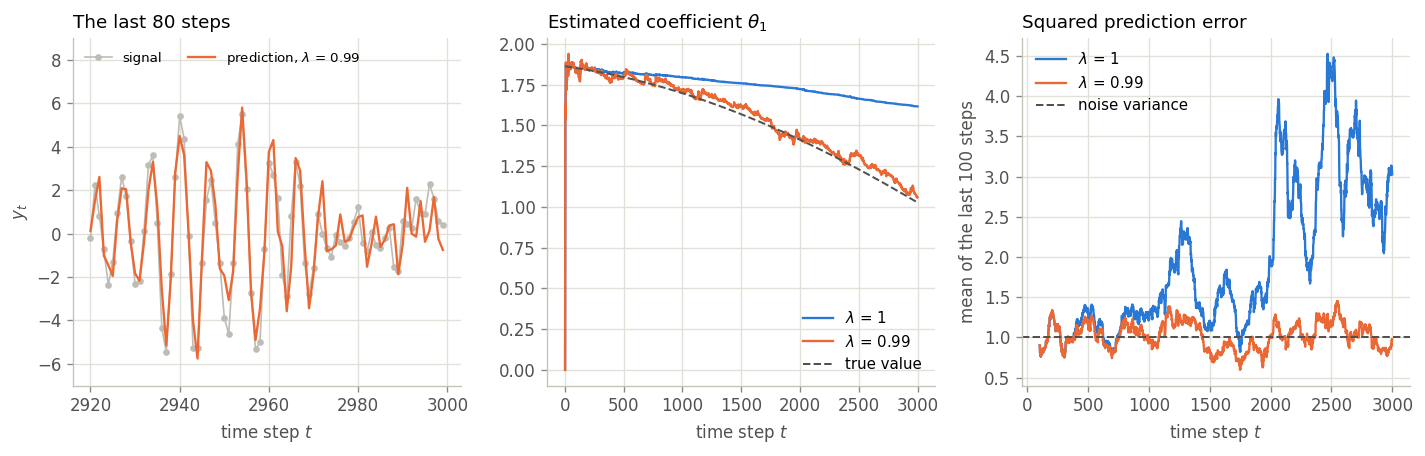

lambda = 1: mean squared prediction error over the last 500 steps 2.90
lambda = 0.99: mean squared prediction error over the last 500 steps 1.02


In [32]:
steps = np.arange(2, n_signal)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.9))
last = slice(len(steps) - 80, len(steps))                # the last 80 steps
axes[0].plot(steps[last], signal[2:][last], "o-", color=POINTS, markersize=3, lw=1, label="signal")
axes[0].plot(steps[last], results[0.99][0][last], color=ORANGE, lw=1.4, label=r"prediction, $\lambda$ = 0.99")
axes[0].set(xlabel="time step $t$", ylabel="$y_t$", ylim=(-7, 9), title="The last 80 steps")
axes[0].legend(loc="upper left", ncol=2, fontsize=8)
for lam, color in [(1.0, BLUE), (0.99, ORANGE)]:
    predictions, coefficients = results[lam]
    axes[1].plot(steps, coefficients[:, 0], color=color, lw=1.4, label=rf"$\lambda$ = {lam:g}")
    squared = (signal[2:] - predictions) ** 2
    axes[2].plot(steps[99:], np.convolve(squared, np.ones(100) / 100, mode="valid"), color=color, lw=1.4,
                 label=rf"$\lambda$ = {lam:g}")
axes[1].plot(steps, theta1_true[2:], "--", color=INK, lw=1.2, label="true value")
axes[1].set(xlabel="time step $t$", title=r"Estimated coefficient $\theta_1$")
axes[1].legend()
axes[2].axhline(1.0, ls="--", color=INK, lw=1.2, label="noise variance")
axes[2].set(xlabel="time step $t$", ylabel="mean of the last 100 steps", title="Squared prediction error")
axes[2].legend()
fig.tight_layout()
plt.show()
for lam, (predictions, _) in results.items():
    print(f"lambda = {lam:g}: mean squared prediction error over the last 500 steps "
          f"{np.mean((signal[-500:] - predictions[-500:]) ** 2):.2f}")

Without forgetting, the estimated coefficient lags further and further behind, because the model tries to describe the whole history with a single set of coefficients, and its prediction error grows. With $\lambda=0.99$, which corresponds to a memory of about $100$ steps, the coefficient follows the slow change, and the prediction error stays close to the variance of the noise, which is the best that any predictor can achieve for this signal.

### Single Observations and Several Outputs: Predicting the Next Position of a Moving Point

With several outputs, the typical setup is the same as in the previous example, except that each observation has several targets. Here, a point moves around the origin on a noisy circular path, and its angular speed increases slowly. Apart from noise, each new position is the previous position rotated by a small angle and pulled slightly towards the origin. We therefore predict both coordinates of the next position (two outputs) from the current position (two inputs). The learned $2\times2$ coefficient matrix describes the rotation, so we can read off the estimated rotation angle per step and compare it with the true one.

In [33]:
def rotation(angle):
    """Matrix that rotates a point by the given angle (in radians)."""
    return np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])

rng = np.random.default_rng(11)
n_steps = 3000
angle_true = np.linspace(0.1, 0.5, n_steps)                 # slowly increasing rotation per step
position = np.zeros((n_steps, 2))
for t in range(1, n_steps):
    position[t] = 0.97 * rotation(angle_true[t]) @ position[t - 1] + rng.normal(0, 0.5, 2)

results_2d = {}
for lam in [1.0, 0.99]:
    model = WeightedRLS(n_features=2, n_outputs=2, forgetting=lam, ridge=1.0)
    predictions, angles = [], []
    for t in range(1, n_steps):
        predictions.append(model.predict(position[t - 1])[0])   # predict the next position ...
        model.update(position[t - 1], position[t])              # ... then learn from it
        Th = model.theta                                         # 2 x 2 coefficient matrix
        angles.append(np.arctan2(Th[0, 1] - Th[1, 0], Th[0, 0] + Th[1, 1]))   # its rotation angle
    results_2d[lam] = (np.array(predictions), np.array(angles))

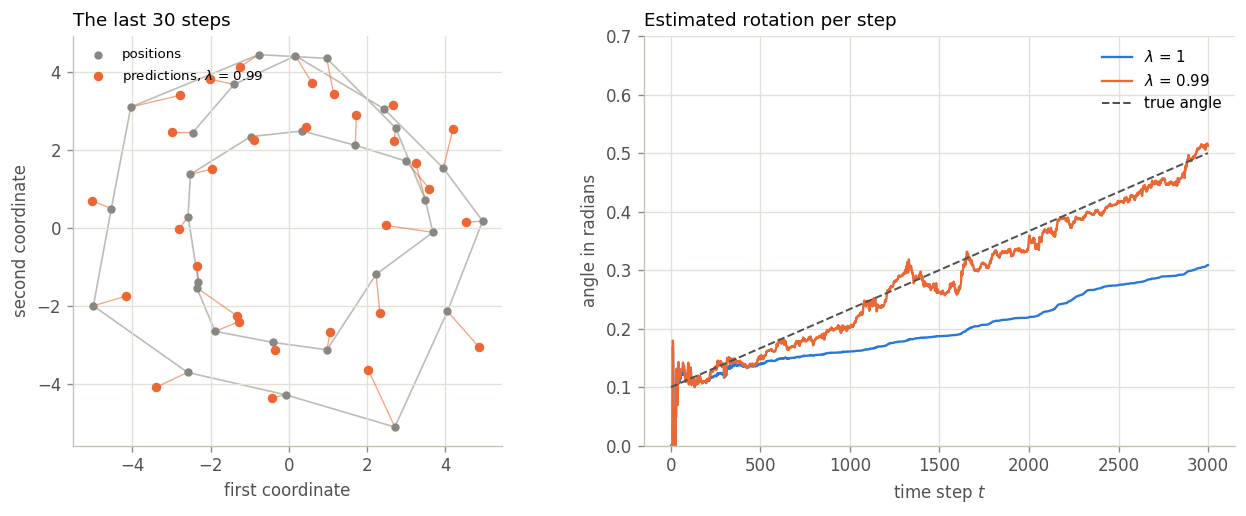

lambda = 1: mean squared prediction error over the last 500 steps 0.83 (noise: 0.50)
lambda = 0.99: mean squared prediction error over the last 500 steps 0.54 (noise: 0.50)


In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))
actual = position[1:][-30:]                                 # the last 30 positions ...
predicted = results_2d[0.99][0][-30:]                       # ... and their one-step predictions
ax1.plot(*actual.T, color=POINTS, lw=1, zorder=1)
for a, p in zip(actual, predicted):                         # connect each prediction with its position
    ax1.plot([p[0], a[0]], [p[1], a[1]], color=ORANGE, lw=0.8, alpha=0.6, zorder=2)
ax1.scatter(*actual.T, s=16, color=MUTED, zorder=3, label="positions")
ax1.scatter(*predicted.T, s=22, color=ORANGE, zorder=4, label=r"predictions, $\lambda$ = 0.99")
ax1.set(aspect="equal", xlabel="first coordinate", ylabel="second coordinate", title="The last 30 steps")
ax1.legend(fontsize=8, loc="upper left")
for lam, color in [(1.0, BLUE), (0.99, ORANGE)]:
    ax2.plot(np.arange(1, n_steps), results_2d[lam][1], color=color, lw=1.4, label=rf"$\lambda$ = {lam:g}")
ax2.plot(angle_true, "--", color=INK, lw=1.2, label="true angle")
ax2.set(xlabel="time step $t$", ylabel="angle in radians", ylim=(0, 0.7), title="Estimated rotation per step")
ax2.legend()
fig.tight_layout()
plt.show()
for lam, (predictions, _) in results_2d.items():
    squared_distance = np.sum((position[1:][-500:] - predictions[-500:]) ** 2, axis=1)
    print(f"lambda = {lam:g}: mean squared prediction error over the last 500 steps {squared_distance.mean():.2f} "
          f"(noise: {2 * 0.5**2:.2f})")

As in the previous example, the model with $\lambda=0.99$ follows the slowly changing rotation, whereas the model without forgetting lags behind, and its predictions are worse. Both outputs share a single $2\times2$ matrix $\mathbf{A}^{-1}$.

### A Whole Data Set in Batches: Fitting a Curve

RLS is not limited to straight lines. Any model that is linear in its coefficients works, for example a polynomial. If a data set is available at once (or arrives in chunks), we can process it in batches with `fit`. Here, we fit a cubic polynomial with the inputs $\mathbf{x}=(1,x,x^2,x^3)^T$ to noisy observations of $y=\sin(x)$, once with single observations and once in batches of $50$. Without forgetting, both give the same coefficients, but the batches are much faster.

single observations: 0.205 s, batches of 50: 0.005 s
largest coefficient difference: 1.2e-14


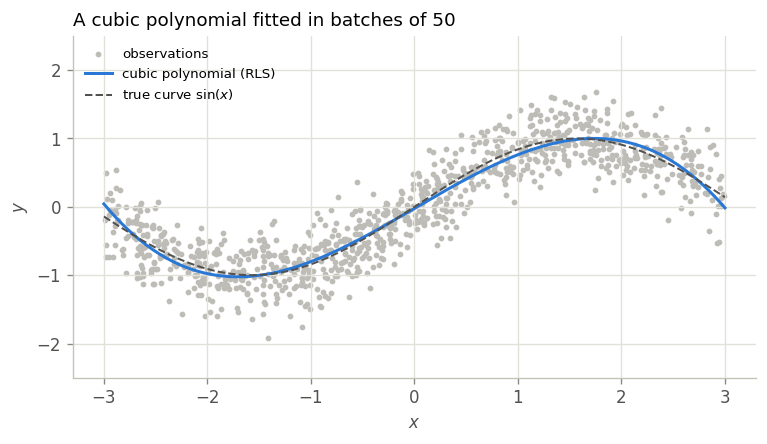

In [35]:
def poly_features(x):
    """Input vectors (1, x, x^2, x^3) as rows."""
    x = np.atleast_1d(x)
    return np.column_stack([np.ones_like(x), x, x**2, x**3])

rng = np.random.default_rng(8)
x_sin = rng.uniform(-3, 3, 1000)
y_sin = np.sin(x_sin) + rng.normal(0, 0.3, 1000)
X_sin = poly_features(x_sin)

start_time = time.perf_counter()
rls_single = WeightedRLS(n_features=4, ridge=0.1)
rls_single.fit(X_sin, y_sin, batch_size=1)
seconds_single = time.perf_counter() - start_time

start_time = time.perf_counter()
rls_batch = WeightedRLS(n_features=4, ridge=0.1)
rls_batch.fit(X_sin, y_sin, batch_size=50)
seconds_batch = time.perf_counter() - start_time

print(f"single observations: {seconds_single:.3f} s, batches of 50: {seconds_batch:.3f} s")
print(f"largest coefficient difference: {np.abs(rls_single.theta - rls_batch.theta).max():.1e}")

fig, ax = plt.subplots(figsize=(6.5, 3.8))
x_grid = np.linspace(-3, 3, 200)
ax.scatter(x_sin, y_sin, s=6, color=POINTS, label="observations")
ax.plot(x_grid, rls_batch.predict(poly_features(x_grid))[:, 0], color=BLUE, label="cubic polynomial (RLS)")
ax.plot(x_grid, np.sin(x_grid), "--", color=INK, lw=1.2, label=r"true curve $\sin(x)$")
ax.set(xlabel="$x$", ylabel="$y$", ylim=(-2.5, 2.5), title="A cubic polynomial fitted in batches of 50")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

### Batches, Several Outputs and Forgetting: Tracking a Changing Shape

In the last example, all features of the class come together. We observe noisy points of a closed curve in batches of $20$ and learn both coordinates at once, as in Section 8. After $1{,}500$ observations, the curve suddenly changes from the heart into an ellipse. We compare a model without forgetting with one that uses $\lambda=0.8$ per batch, which corresponds to a memory of about $1/(1-0.8)=5$ batches, or $100$ observations.

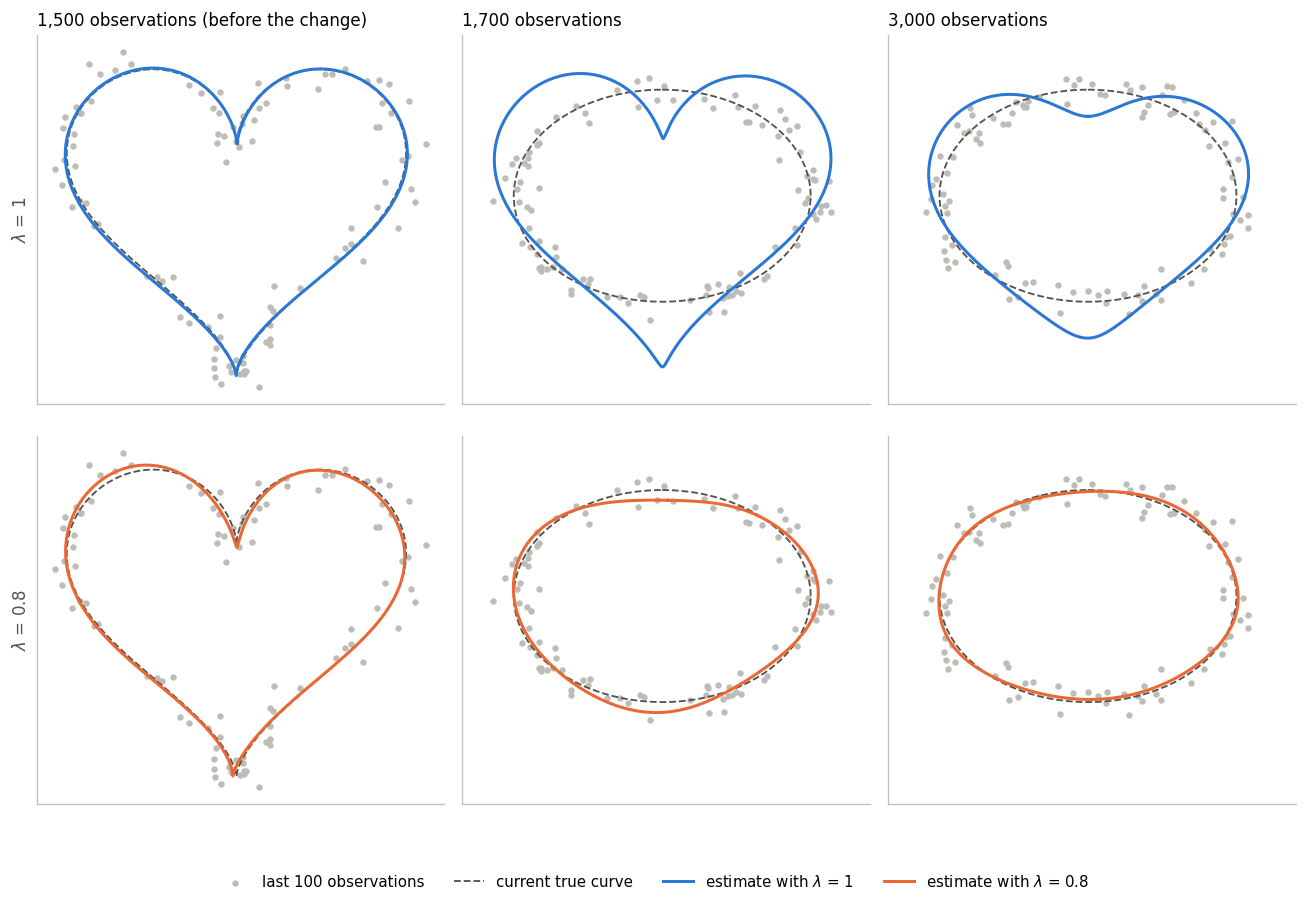

In [36]:
def ellipse(t):
    """Points (u, v) of an ellipse, one row per parameter value."""
    return np.column_stack([14 * np.sin(t), 10 * np.cos(t)])

rng = np.random.default_rng(9)
n_shape, mu, change = 3000, 20, 1500
t_shape = rng.uniform(0, 2 * np.pi, n_shape)
true_points = np.where(np.arange(n_shape)[:, None] < change, heart(t_shape), ellipse(t_shape))
Y_shape = true_points + rng.normal(0, 1.0, (n_shape, 2))
X_shape = fourier_features(t_shape)

models = {1.0: WeightedRLS(9, 2, forgetting=1.0, ridge=0.01),
          0.8: WeightedRLS(9, 2, forgetting=0.8, ridge=0.01)}
snapshots = {lam: {} for lam in models}
for start in range(0, n_shape, mu):
    for lam, model in models.items():
        model.update(X_shape[start:start + mu], Y_shape[start:start + mu])
        if start + mu in (1500, 1700, 3000):
            snapshots[lam][start + mu] = model.theta.copy()

fig, axes = plt.subplots(2, 3, figsize=(11, 7.6), sharex=True, sharey=True)
titles = {1500: "1,500 observations (before the change)", 1700: "1,700 observations", 3000: "3,000 observations"}
for row, (lam, color) in enumerate([(1.0, BLUE), (0.8, ORANGE)]):
    for col, n in enumerate([1500, 1700, 3000]):
        ax = axes[row, col]
        shape_now = heart if n <= change else ellipse
        ax.scatter(*Y_shape[n - 100:n].T, s=8, color=POINTS, label="last 100 observations")
        ax.plot(*shape_now(t_grid).T, "--", color=INK, lw=1.1, label="current true curve")
        ax.plot(*(fourier_features(t_grid) @ snapshots[lam][n]).T, color=color, label=rf"estimate with $\lambda$ = {lam:g}")
        ax.set(aspect="equal", xticks=[], yticks=[])
        if row == 0:
            ax.set_title(titles[n], fontsize=10)
        if col == 0:
            ax.set_ylabel(rf"$\lambda$ = {lam:g}")
handles, labels = axes[0, 0].get_legend_handles_labels()
handles.append(axes[1, 0].get_lines()[-1]); labels.append(axes[1, 0].get_lines()[-1].get_label())
fig.legend(handles, labels, loc="lower center", ncol=4)
fig.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

Without forgetting, the estimate after the change is a blend of both shapes, and even $1{,}500$ observations later it still carries the heart along. With $\lambda=0.8$ per batch, the estimate has adopted the ellipse after a few batches.

## 11. Summary

The core of the class consists of the batch equations of the blog post,

$$
\begin{aligned}
\mathbf{E}_\mu &= \mathbf{Y}_\mu-\mathbf{X}_\mu\boldsymbol{\Theta}_n, \\
\boldsymbol{\Delta}_\mu &= \mathbf{A}_n^{-1}\mathbf{X}_\mu^T\big(\lambda_n\mathbf{W}_\mu^{-1}+\mathbf{X}_\mu\mathbf{A}_n^{-1}\mathbf{X}_\mu^T\big)^{-1}, \\
\boldsymbol{\Theta}_{n+\mu} &= \boldsymbol{\Theta}_n+\boldsymbol{\Delta}_\mu\mathbf{E}_\mu, \\
\mathbf{A}_{n+\mu}^{-1} &= \frac{1}{\lambda_n}\Big(\mathbf{A}_n^{-1}-\boldsymbol{\Delta}_\mu\mathbf{X}_\mu\mathbf{A}_n^{-1}\Big),
\end{aligned}
$$

with $\boldsymbol{\Theta}_0=\mathbf{0}$, $\mathbf{A}_0^{-1}=\rho^{-1}\mathbf{I}$ and $\lambda_0=1$. In `WeightedRLS.update`, they correspond to these lines:

```python
lam_n = 1.0 if self.n_seen == 0 else self.forgetting   # lambda_0 = 1

E_mu = Y_mu - X_mu @ self.theta                          # prediction errors E_mu
XA = X_mu @ self.A_inv                                   # X_mu A_n^{-1}, shape (mu, k)
S = lam_n * np.diag(1.0 / w_mu) + XA @ X_mu.T            # lambda_n W_mu^{-1} + X_mu A_n^{-1} X_mu^T
Delta_mu = np.linalg.solve(S, XA).T                      # gain A_n^{-1} X_mu^T S^{-1}, shape (k, mu)
self.theta = self.theta + Delta_mu @ E_mu                # Theta_{n+mu} = Theta_n + Delta_mu E_mu
A_inv = (self.A_inv - Delta_mu @ XA) / lam_n             # A_{n+mu}^{-1}
self.A_inv = 0.5 * (A_inv + A_inv.T)                     # keep A^{-1} exactly symmetric
```

A few practical recommendations follow from the examples:

- Add a column of ones to the inputs if the model needs an intercept.
- Choose $\rho$ small compared with the typical size of $\mathbf{x}^T\mathbf{x}$, but not extremely small (Section 3). For inputs of order one, values between $10^{-3}$ and $1$ work well.
- Use $\lambda=1$ if the relationship does not change. If it may change slowly, a forgetting factor slightly below $1$, such as $0.99$, is the usual choice; in general, choose $\lambda$ from the desired memory of about $1/(1-\lambda)$ updates (Sections 5 and 10). In batch mode, the memory is counted in batches.
- Observation weights are only needed if some observations are known to be more reliable than others (Section 4). Otherwise, the default weights of $1$ are the right choice.
- Keep $\mathbf{A}^{-1}$ symmetric, in particular with forgetting (Section 6).
- Moderate batch sizes are usually fastest (Section 7).
- With forgetting, directions of the input space that receive no new information for a long time are forgotten as well, and the corresponding entries of $\mathbf{A}^{-1}$ grow. Make sure that the inputs keep varying, or choose $\lambda$ closer to $1$.